In [2]:
import matplotlib.pyplot as plt
import pandas as pd

In [5]:
raw_data = pd.read_parquet("/Users/thiago/Library/Mobile Documents/com~apple~CloudDocs/cross_sectional_return_prediction/data/raw/yahoo_raw.parquet")

In [6]:
raw_data.head()

Price           Close                                                          \
Ticker           AAPL       AMZN        CVX      GOOGL          GS        JPM   
Date                                                                            
2018-01-02  40.304176  59.450500  89.452377  53.220638  213.144272  85.901283   
2018-01-03  40.297146  60.209999  90.104454  54.128632  211.160141  85.988792   
2018-01-04  40.484352  60.479500  89.823975  54.338890  214.111282  87.220657   
2018-01-05  40.945259  61.457001  89.676750  55.059433  213.019196  86.660706   
2018-01-08  40.793179  62.343498  90.118477  55.253830  209.926270  86.788704   

Price                                                    ...    Volume  \
Ticker             KO        LLY        META       MSFT  ...       JPM   
Date                                                     ...             
2018-01-02  35.250355  75.026703  180.007401  78.870361  ...  13578800   
2018-01-03  35.172951  75.434258  183.232086  79.237411  ...  11901000   
2018-01-04  35.668335  75.770950  182.894745  79.934822  ...  12953700   
2018-01-05  35.660610  76.701256  185.395096  80.925850  ...  14155000   
2018-01-08  35.606415  76.311417  186.813950  81.008430  ...  12466500   

Price                                                                  \
Ticker            KO      LLY      META      MSFT       NVDA      PEP   
Date                                                                    
2018-01-02  10872200  3456700  18151900  22483800  355616000  4165800   
2018-01-03  12635600  3078400  16886600  26061400  914704000  4224000   
2018-01-04  12709400  2462500  13880900  21912000  583268000  3147000   
2018-01-05  13113100  2946300  13574500  23407100  580124000  2714200   
2018-01-08   7068600  3251400  17994700  22113000  881216000  5730400   

Price                                   
Ticker           PG      UNH       XOM  
Date                                    
2018-01-02  7558900  3485000  11469300  
2018-01-03  5863600  2417600  13957700  
2018-01-04  6322500  2749100  10863000  
2018-01-05  5949700  2432800  11047600  
2018-01-08  4860700  2850800  10927100  

[5 rows x 75 columns]

In [15]:
# reshape from wide (Yahoo format) to long: date, ticker, close
if isinstance(raw_data.columns, pd.MultiIndex):
    # expected from yfinance: level 0 = field (Open/High/Low/Close/Volume), level 1 = ticker
    close_wide = raw_data["Close"].copy()
else:
    # fallback: single-level columns
    close_wide = raw_data.copy()

long_data = (
    close_wide
    .reset_index()
    .melt(id_vars="Date", var_name="ticker", value_name="close")
    .rename(columns={"Date": "date"})
    .dropna(subset=["close"])
    .sort_values(["ticker", "date"])
    .reset_index(drop=True)
)

long_data.head()

,date,ticker,close
0,2018-01-02,AAPL,40.304176
1,2018-01-03,AAPL,40.297146
2,2018-01-04,AAPL,40.484352
3,2018-01-05,AAPL,40.945259
4,2018-01-08,AAPL,40.793179


In [18]:
long_data.columns

Index(['date', 'ticker', 'close'], dtype='object')

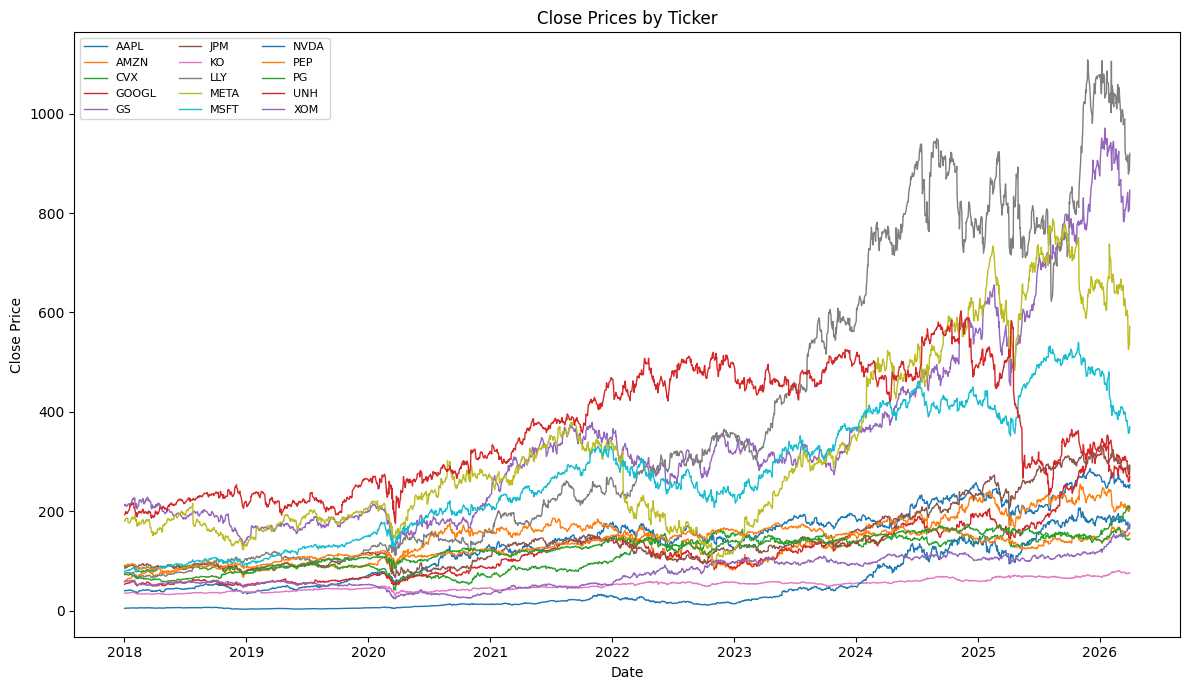

In [19]:
# plot the prices over time
plt.figure(figsize=(12, 7))
for ticker, ticker_data in long_data.groupby("ticker"):
    plt.plot(ticker_data["date"], ticker_data["close"], label=ticker, linewidth=1)

plt.xlabel("Date")
plt.ylabel("Close Price")
plt.title("Close Prices by Ticker")
plt.legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.show()